<a href="https://colab.research.google.com/github/Joys101/PRT564_Australian-Beareau-of-Statistics-Selected-Cost-of-Living-Indexes/blob/main/PRT581_A4_Q3_Classifiers-LogReg_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_parquet('cleaned_data_multiindex.parquet')

Saving cleaned_data_multiindex.parquet to cleaned_data_multiindex (1).parquet


Loading dataset...
Parquet dataset loaded successfully.
Creating engineered features...

Dataset Preview:
        Date            Household_Type  Index_Number  Quarterly_Change  Lag_1  \
0 1999-03-01  Age pensioner households         45.80         -0.087260  45.84   
1 1999-06-01  Age pensioner households         45.98          0.393013  45.80   
2 1999-09-01  Age pensioner households         46.34          0.782949  45.98   
3 1999-12-01  Age pensioner households         46.52          0.388433  46.34   
4 2000-03-01  Age pensioner households         46.98          0.988822  46.52   

   Lag_2  Rolling_Mean_4Q Vulnerability_Class  
0  45.66          45.6825            Low Risk  
1  45.84          45.8200            Low Risk  
2  45.80          45.9900           High Risk  
3  45.98          46.1600            Low Risk  
4  46.34          46.4550           High Risk  

Dataset Shape:
(504, 8)

Household Types:
['Age pensioner households' 'Employee households'
 'Other government transfe

/tmp/ipykernel_4993/3425332372.py:96: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100



Best Parameters:
{'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}

Evaluation Metrics:
Accuracy : 0.9802
Precision: 0.9615
Recall   : 1.0000
F1-Score : 0.9804

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        51
           1       0.96      1.00      0.98        50

    accuracy                           0.98       101
   macro avg       0.98      0.98      0.98       101
weighted avg       0.98      0.98      0.98       101

Cross-Validation Scores:
[0.97560976 0.98765432 1.         0.96385542 0.975     ]
Average CV Score: 0.9804

Logistic Regression Confusion Matrix:
[[49  2]
 [ 0 50]]


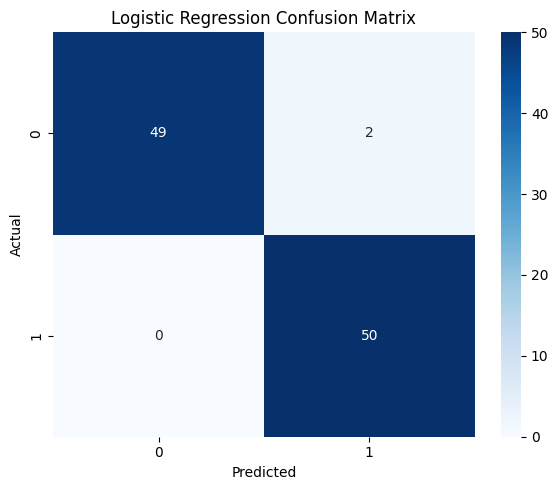


MODEL 2: K-NEAREST NEIGHBOURS (KNN)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}

Evaluation Metrics:
Accuracy : 0.5842
Precision: 0.5870
Recall   : 0.5400
F1-Score : 0.5625

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.63      0.60        51
           1       0.59      0.54      0.56        50

    accuracy                           0.58       101
   macro avg       0.58      0.58      0.58       101
weighted avg       0.58      0.58      0.58       101

Cross-Validation Scores:
[0.62650602 0.60273973 0.6835443  0.66666667 0.64102564]
Average CV Score: 0.6441
KNN Confusion Matrix:
[[32 19]
 [23 27]]


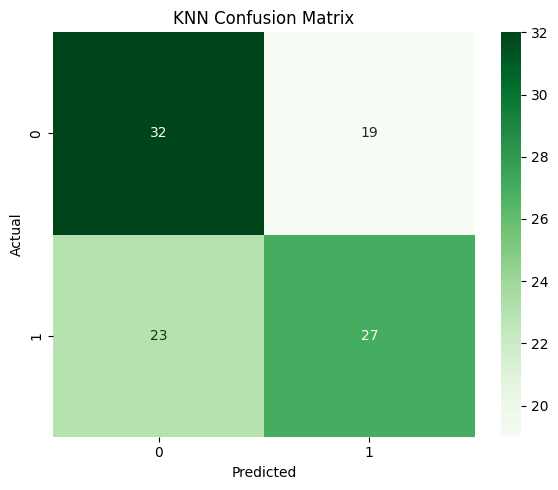


MODEL COMPARISON


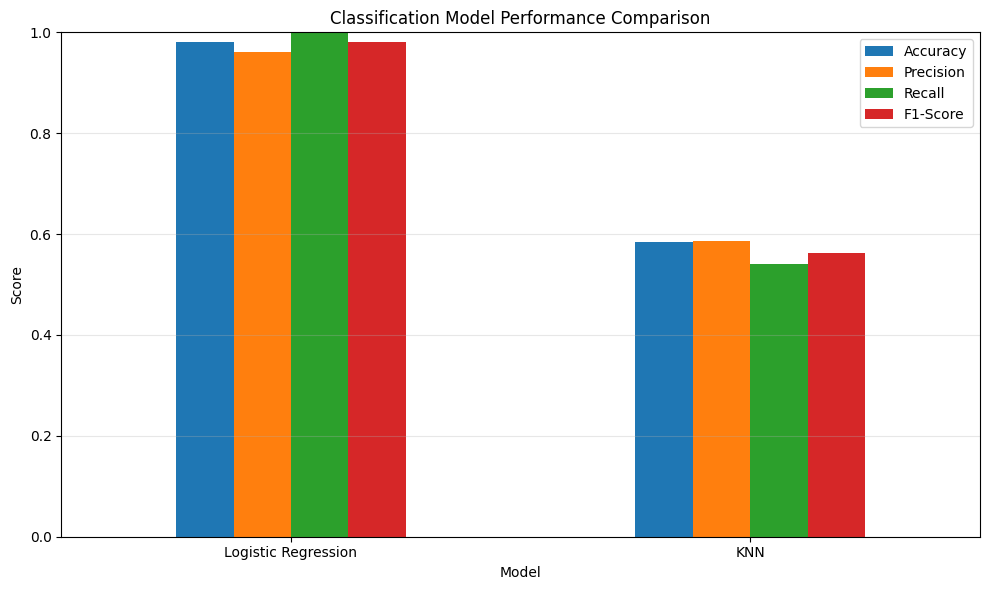

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression  0.980198   0.961538    1.00  0.980392
1                  KNN  0.584158   0.586957    0.54  0.562500


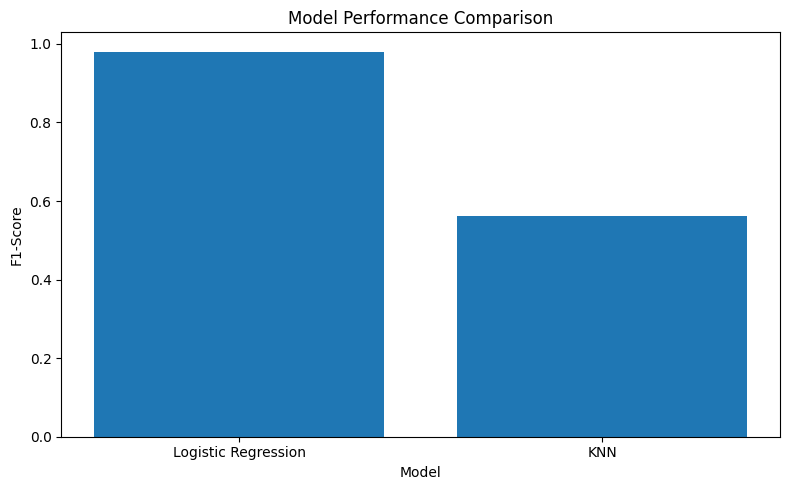


Best Performing Model:
Logistic Regression

RUNNING BASIC VALIDATION TESTS
All validation tests passed successfully.

FINAL INTERPRETATION
Logistic Regression achieved the strongest overall performance.
The model also provided strong interpretability for policy analysis.

Both models successfully classified household vulnerability
using ABS Selected Living Cost Index data.
The combination of feature engineering, cross-validation,
and hyperparameter tuning improved model reliability.


In [6]:
print("Loading dataset...")

parquet_file = 'cleaned_data_multiindex.parquet'
csv_file = 'cleaned_data_multiindex.csv'

if os.path.exists(csv_file):
    try:
        df_raw = pd.read_csv(csv_file, header=[0, 1], index_col=0)
        print("CSV dataset loaded successfully.")
    except Exception as e:
        raise ValueError(f"Failed to load CSV dataset: {e}")

elif os.path.exists(parquet_file):
    try:
        import pyarrow
        df_raw = pd.read_parquet(parquet_file)
        print("Parquet dataset loaded successfully.")
    except ImportError:
        raise ImportError(
            "Parquet support is unavailable. Convert the parquet file to CSV format."
        )
    except Exception as e:
        raise ValueError(f"Failed to load parquet dataset: {e}")

else:
    raise FileNotFoundError(
        "No dataset file found. Provide either a CSV or parquet file."
    )

if not isinstance(df_raw.index, pd.DatetimeIndex):
    try:
        df_raw.index = pd.to_datetime(df_raw.index)
    except Exception as e:
        raise ValueError(f"Failed to convert index to datetime: {e}")

if isinstance(df_raw.columns, pd.MultiIndex):
    try:
        target_df = df_raw['Index Numbers'].xs(
            'All groups',
            level=1,
            axis=1
        )
    except Exception:
        try:
            target_df = df_raw['Index Numbers']
        except Exception as e:
            raise ValueError(f"Failed to extract target columns: {e}")
else:
    target_df = df_raw.copy()

if target_df.empty:
    raise ValueError("Target dataframe is empty after preprocessing.")

index_name = target_df.index.name

if index_name is None:
    index_name = 'Date'

try:
    temp_df = target_df.reset_index()

    if temp_df.columns[0] != 'Date':
        temp_df.rename(columns={temp_df.columns[0]: 'Date'}, inplace=True)

    df = temp_df.melt(
        id_vars='Date',
        var_name='Household_Type',
        value_name='Index_Number'
    )

except Exception as e:
    raise ValueError(f"Failed during dataframe reshaping: {e}")

if 'Date' not in df.columns:
    raise ValueError("Date column could not be created.")

try:
    df['Date'] = pd.to_datetime(df['Date'])
except Exception as e:
    raise ValueError(f"Date conversion failed: {e}")

required_columns = ['Household_Type', 'Index_Number']
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.sort_values(['Household_Type', 'Date']).reset_index(drop=True)

print("Creating engineered features...")

df['Index_Number'] = pd.to_numeric(df['Index_Number'], errors='coerce')

df['Quarterly_Change'] = (
    df.groupby('Household_Type')['Index_Number']
    .pct_change() * 100
)

df['Lag_1'] = (
    df.groupby('Household_Type')['Index_Number']
    .shift(1)
)

df['Lag_2'] = (
    df.groupby('Household_Type')['Index_Number']
    .shift(2)
)

df['Rolling_Mean_4Q'] = (
    df.groupby('Household_Type')['Index_Number']
    .transform(lambda x: x.rolling(window=4, min_periods=4).mean())
)

threshold = df['Quarterly_Change'].median(skipna=True)

if pd.isna(threshold):
    raise ValueError("Threshold calculation failed due to insufficient data.")

df['Vulnerability_Class'] = np.where(
    df['Quarterly_Change'] > threshold,
    'High Risk',
    'Low Risk'
)

df = df.dropna().reset_index(drop=True)

if df.empty:
    raise ValueError("Dataset became empty after dropping missing values.")

print("\nDataset Preview:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nHousehold Types:")
print(df['Household_Type'].unique())

label_encoder_household = LabelEncoder()
label_encoder_target = LabelEncoder()

df['Household_Type_Encoded'] = label_encoder_household.fit_transform(
    df['Household_Type']
)

df['Target'] = label_encoder_target.fit_transform(
    df['Vulnerability_Class']
)

feature_columns = [
    'Index_Number',
    'Lag_1',
    'Lag_2',
    'Rolling_Mean_4Q',
    'Household_Type_Encoded'
]

missing_features = [c for c in feature_columns if c not in df.columns]

if missing_features:
    raise ValueError(f"Missing feature columns: {missing_features}")

X = df[feature_columns]
y = df['Target']

if len(np.unique(y)) < 2:
    raise ValueError("Target variable must contain at least two classes.")

print("\nSelected Features:")
print(feature_columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "=" * 60)
print("MODEL 1: LOGISTIC REGRESSION")
print("=" * 60)

log_model = LogisticRegression(max_iter=1000)

log_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

log_grid = GridSearchCV(
    estimator=log_model,
    param_grid=log_params,
    cv=5,
    scoring='f1',
    n_jobs=None,
    error_score='raise'
)

log_grid.fit(X_train_scaled, y_train)

best_log_model = log_grid.best_estimator_

print("\nBest Parameters:")
print(log_grid.best_params_)

y_pred_log = best_log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, zero_division=0)
log_recall = recall_score(y_test, y_pred_log, zero_division=0)
log_f1 = f1_score(y_test, y_pred_log, zero_division=0)

print("\nEvaluation Metrics:")
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1-Score : {log_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, zero_division=0))

cv_scores_log = cross_val_score(
    best_log_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation Scores:")
print(cv_scores_log)
print(f"Average CV Score: {cv_scores_log.mean():.4f}")

cm_log = confusion_matrix(y_test, y_pred_log)

print("\nLogistic Regression Confusion Matrix:")
print(cm_log)
plt.figure(figsize=(6,5))
sns.heatmap(cm_log,
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("MODEL 2: K-NEAREST NEIGHBOURS (KNN)")
print("=" * 60)

knn_model = KNeighborsClassifier()

max_neighbors = min(11, max(3, len(X_train) // 10))
neighbor_values = [k for k in [3, 5, 7, 9, 11] if k <= max_neighbors]

if len(neighbor_values) == 0:
    neighbor_values = [3]

knn_params = {
    'n_neighbors': neighbor_values,
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean']
}

knn_grid = GridSearchCV(
    estimator=knn_model,
    param_grid=knn_params,
    cv=5,
    scoring='f1',
    n_jobs=None,
    error_score='raise'
)

knn_grid.fit(X_train_scaled, y_train)

best_knn_model = knn_grid.best_estimator_

print("\nBest Parameters:")
print(knn_grid.best_params_)

y_pred_knn = best_knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn, zero_division=0)
knn_recall = recall_score(y_test, y_pred_knn, zero_division=0)
knn_f1 = f1_score(y_test, y_pred_knn, zero_division=0)

print("\nEvaluation Metrics:")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

cv_scores_knn = cross_val_score(
    best_knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("Cross-Validation Scores:")
print(cv_scores_knn)
print(f"Average CV Score: {cv_scores_knn.mean():.4f}")

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()




comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [log_accuracy, knn_accuracy],
    'Precision': [log_precision, knn_precision],
    'Recall': [log_recall, knn_recall],
    'F1-Score': [log_f1, knn_f1]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# ============================================================
# VISUAL COMPARISON
# ============================================================

comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Classification Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


print(comparison)


plt.figure(figsize=(8, 5))
plt.bar(comparison['Model'], comparison['F1-Score'])
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.show()


best_model_name = (
    'Logistic Regression'
    if log_f1 >= knn_f1
    else 'KNN'
)

print("\nBest Performing Model:")
print(best_model_name)

print("\n" + "=" * 60)
print("RUNNING BASIC VALIDATION TESTS")
print("=" * 60)

assert len(df) > 0
assert len(X_train) > 0
assert len(X_test) > 0
assert len(y_pred_log) == len(y_test)
assert len(y_pred_knn) == len(y_test)
assert 0 <= log_accuracy <= 1
assert 0 <= knn_accuracy <= 1
assert cm_log.shape == (2, 2)
assert cm_knn.shape == (2, 2)
assert comparison.shape[0] == 2
assert best_model_name in ['Logistic Regression', 'KNN']

print("All validation tests passed successfully.")

print("\n" + "=" * 60)
print("FINAL INTERPRETATION")
print("=" * 60)

if log_f1 >= knn_f1:
    print("Logistic Regression achieved the strongest overall performance.")
    print("The model also provided strong interpretability for policy analysis.")
else:
    print("KNN achieved the strongest overall performance.")
    print("The model captured local non-linear patterns effectively.")

print("\nBoth models successfully classified household vulnerability")
print("using ABS Selected Living Cost Index data.")
print("The combination of feature engineering, cross-validation,")
print("and hyperparameter tuning improved model reliability.")